
First 5 Rows:

   PassengerId  Survived  Pclass                                                 Name     Sex   Age  SibSp  Parch            Ticket     Fare Cabin Embarked
0            1         0       3                              Braund, Mr. Owen Harris    male  22.0      1      0         A/5 21171   7.2500   NaN        S
1            2         1       1  Cumings, Mrs. John Bradley (Florence Briggs Thayer)  female  38.0      1      0          PC 17599  71.2833   C85        C
2            3         1       3                               Heikkinen, Miss. Laina  female  26.0      0      0  STON/O2. 3101282   7.9250   NaN        S
3            4         1       1         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1      0            113803  53.1000  C123        S
4            5         0       3                             Allen, Mr. William Henry    male  35.0      0      0            373450   8.0500   NaN        S

Dataset Info:

<class 'pandas.core.frame.DataFr

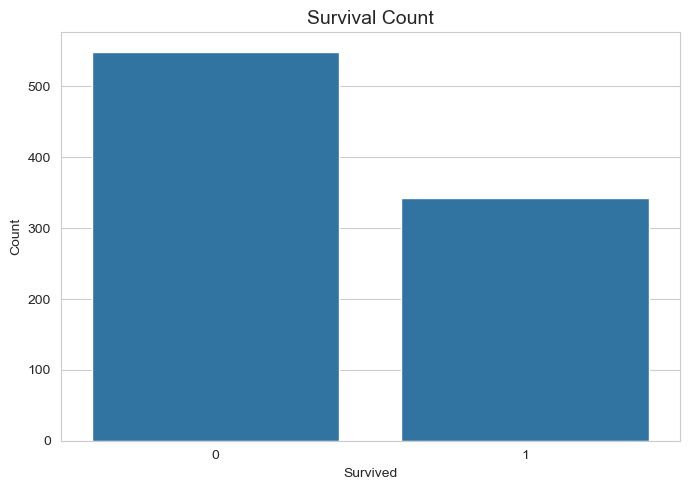

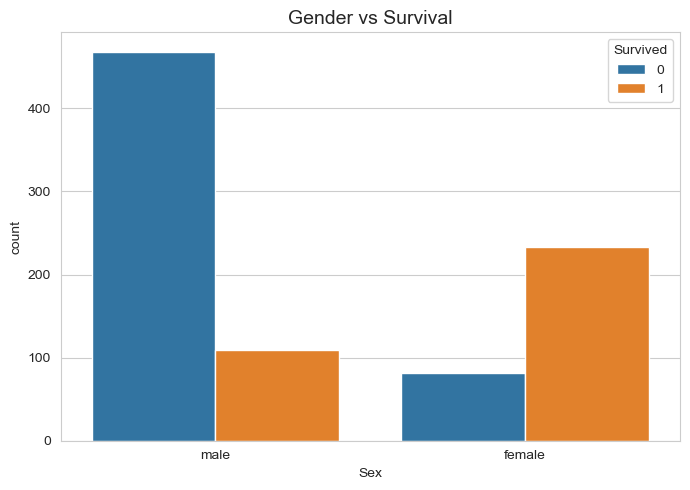

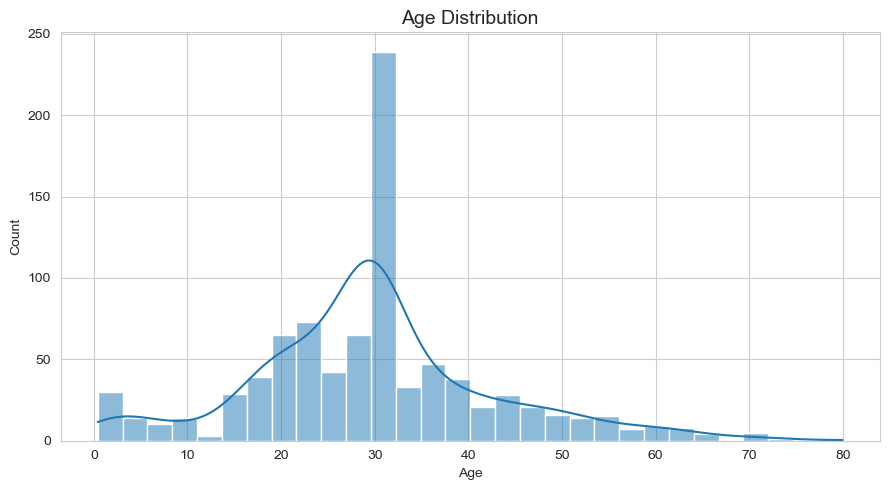

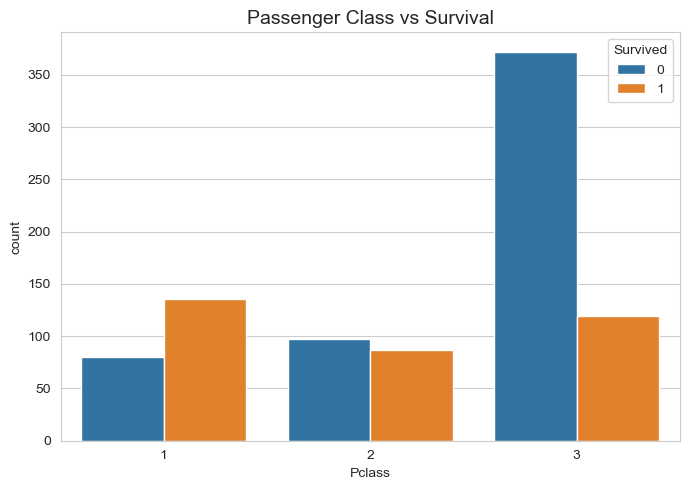

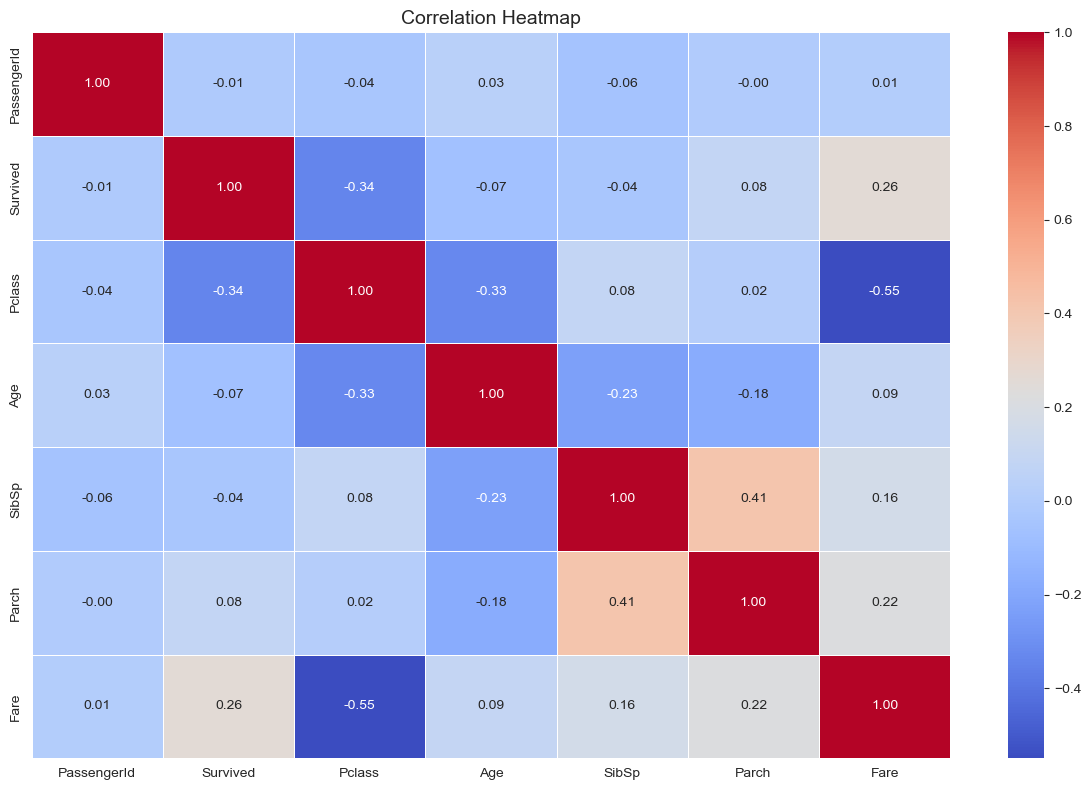

In [3]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------
# Pandas Display Settings (No Truncate)
# -----------------------------------
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

# -----------------------------------
# Load Titanic dataset
# -----------------------------------
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

# -----------------------------------
# Show first 5 rows
# -----------------------------------
print("\nFirst 5 Rows:\n")
print(df.head().to_string())

# -----------------------------------
# Dataset information
# -----------------------------------
print("\nDataset Info:\n")
df.info()

# -----------------------------------
# Missing values
# -----------------------------------
print("\nMissing Values:\n")
print(df.isnull().sum().to_string())

# -----------------------------------
# Data Cleaning
# -----------------------------------

# Fill missing Age values with mean
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Fill missing Embarked values
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin column
df.drop('Cabin', axis=1, inplace=True)

# -----------------------------------
# Seaborn Style
# -----------------------------------
sns.set_style("whitegrid")

# -----------------------------
# Survival Count
# -----------------------------
plt.figure(figsize=(7, 5))

sns.countplot(x='Survived', data=df)

plt.title("Survival Count", fontsize=14)
plt.xlabel("Survived")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

# -----------------------------
# Gender vs Survival
# -----------------------------
plt.figure(figsize=(7, 5))

sns.countplot(x='Sex', hue='Survived', data=df)

plt.title("Gender vs Survival", fontsize=14)

plt.tight_layout()
plt.show()

# -----------------------------
# Age Distribution
# -----------------------------
plt.figure(figsize=(9, 5))

sns.histplot(df['Age'], bins=30, kde=True)

plt.title("Age Distribution", fontsize=14)
plt.xlabel("Age")

plt.tight_layout()
plt.show()

# -----------------------------
# Passenger Class vs Survival
# -----------------------------
plt.figure(figsize=(7, 5))

sns.countplot(x='Pclass', hue='Survived', data=df)

plt.title("Passenger Class vs Survival", fontsize=14)

plt.tight_layout()
plt.show()

# -----------------------------
# Correlation Heatmap
# -----------------------------
plt.figure(figsize=(12, 8))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=14)

plt.tight_layout()
plt.show()